In [2]:
# !pip install torchmetrics


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from torch import nn
import torch
from matplotlib import pyplot as plt


device = "cpu"



In [5]:
# Accuracy calculation helper function
def Accuracy(known_outcome,prediction,types=1):
  """
  For accuracy calculation in percentage
  arguments:
  known_outcome -> as in known outcome
  prediction -> As in prediction from our model

  returns accuracy in percentage
  """
  if type == 1:
    mae = torch.mean(torch.abs(known_outcome - prediction)).item()
    return mae
  else:
    acc = torch.eq(known_outcome,prediction).sum().item()
    return (acc/len(known_outcome))*100


# Visualization curve helper function
def prediction_curve(
    training_x,training_label,
    test_x, test_label,
    prediction_label = None
):
  """
  For Visualization
  arguments:
  training_x -> Training data
  training_label -> Training label
  test_x -> Test data
  test_label -> test label
  prediction_label -> As in prediction label from our model

  returns accuracy in percentage
  """
  plt.figure(figsize=(10,4))
  plt.scatter(training_x,training_label,s=4,c="b",label="Training data")
  plt.scatter(test_x,test_label,s=4,c="g",label="Training data")
  if prediction_label is not None:
    plt.scatter(test_x,prediction_label,s=4,c="r",label="Training data")


In [6]:
# y=ax + b (Linear regression)
start = 0
end = 1
step=0.01
a=0.7
b=0.3
epoch = 10000
x=torch.arange(start,end,step).unsqueeze(dim=1)
y=a*x + b
test_split = int(0.8 * len(x))
x_train,x_test=x[:test_split],x[test_split:]
# x_train.shape,x_test.shape

y_label_train,y_label_test=y[:test_split],y[test_split:]
x_train ,x_test, y_label_train, y_label_test=x_train.to(device) ,x_test.to(device), y_label_train.to(device), y_label_test.to(device)



In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.input_parameters = nn.Sequential(
        nn.Linear(in_features=1,out_features=16),
        nn.Linear(in_features=16,out_features=16),
        nn.Linear(in_features=16,out_features=1)
    )
  def forward(self,x:torch.tensor):
    return self.input_parameters(x)


In [8]:
model1 = LinearRegressionModel()

In [9]:
loss = nn.L1Loss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.01)

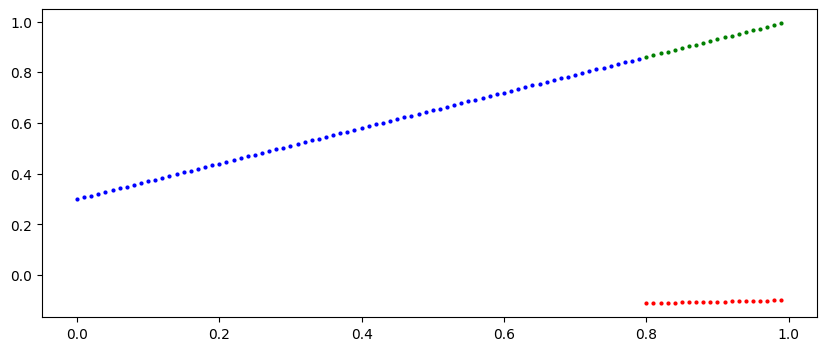

In [10]:
model1.eval()
with torch.inference_mode():
  logit = model1(x_test)

prediction_curve(
    training_x= x_train,
    training_label= y_label_train,
    test_x= x_test,
    test_label= y_label_test,
    prediction_label=logit
)

**train for loss optimize zero lobos**

In [11]:
for i in range(epoch):
  model1.train()
  logit = model1(x_train)
  losses = loss(y_label_train,logit)
  label = torch.round(torch.sigmoid(logit))
  # Accuracy
  accuracy = Accuracy(y_label_train,label)
  optimizer.zero_grad()
  losses.backward()
  optimizer.step()



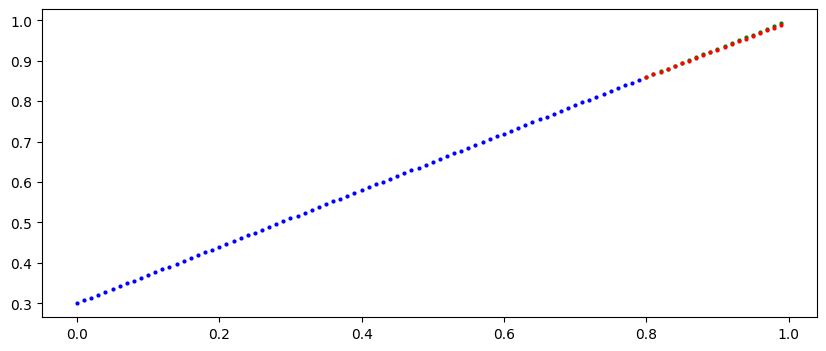

In [12]:
model1.eval()
with torch.inference_mode():
  logit = model1(x_test)

prediction_curve(
    training_x= x_train,
    training_label= y_label_train,
    test_x= x_test,
    test_label= y_label_test,
    prediction_label=logit
)


In [13]:
# Accuracy(y_label_test,logit,types=1)
mae = torch.mean(torch.abs(y_label_test - logit)).item()
mae

0.002077645156532526

In [17]:
testing=torch.tensor([[1,2,2],
                      [2,4,5]])
# testing
another_test = torch.randn_like(x)
another_test

tensor([[-1.6097e+00],
        [ 1.6012e+00],
        [-1.3227e+00],
        [ 9.1497e-01],
        [ 1.0024e+00],
        [ 1.4078e+00],
        [ 2.4150e+00],
        [ 3.4371e-01],
        [ 5.5636e-01],
        [-2.4841e-01],
        [-8.8674e-01],
        [ 7.8005e-01],
        [-8.5579e-01],
        [ 1.6891e+00],
        [ 5.2488e-01],
        [-9.0072e-01],
        [ 9.6344e-01],
        [-6.7282e-01],
        [ 2.0094e-01],
        [-1.0012e+00],
        [ 1.8026e+00],
        [ 6.1180e-01],
        [-3.2259e-01],
        [-7.5636e-02],
        [-9.2200e-01],
        [ 7.8466e-01],
        [-1.3900e+00],
        [-2.4689e+00],
        [-5.4128e-02],
        [ 2.0086e+00],
        [-1.4086e+00],
        [-6.4409e-01],
        [-7.4690e-01],
        [-1.8799e-01],
        [ 5.8828e-01],
        [ 9.7920e-01],
        [-6.1297e-03],
        [ 2.9319e-01],
        [-8.1327e-01],
        [ 1.6001e+00],
        [ 2.1638e-01],
        [ 7.1826e-01],
        [ 6.2565e-02],
        [ 5